In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [7]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [8]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [10]:
print("First 10 Rows")
print(df.head())

First 10 Rows
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [11]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [12]:
df.drop_duplicates(inplace=True)

print("\nDataset Shape:", df.shape)



Dataset Shape: (400, 5)


In [17]:
le = LabelEncoder()

df["Purchased"] = le.fit_transform(df["Purchased"])

In [19]:
X = df[["Age"]]
y = df["Purchased"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy")
print(round(accuracy * 100, 2), "%")


print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy
80.0 %

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.71      0.82        51
           1       0.65      0.97      0.78        29

    accuracy                           0.80        80
   macro avg       0.81      0.84      0.80        80
weighted avg       0.86      0.80      0.80        80



In [32]:
age = int(input("\nEnter Age: "))

user = pd.DataFrame([[age]], columns=["Age"])

user_scaled = scaler.transform(user)

prediction = model.predict(user_scaled)

probability = model.predict_proba(user_scaled)

print("\nProbability")

print("Not Purchased :", round(probability[0][0] * 100, 2), "%")
print("Purchased :", round(probability[0][1] * 100, 2), "%")

if prediction[0] == 1:
    print("\nRESULT : ")
else:
    print("\nRESULT : NOT PURCHASED")



Enter Age: 46

Probability
Not Purchased : 0.0 %
Purchased : 100.0 %

RESULT : 


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


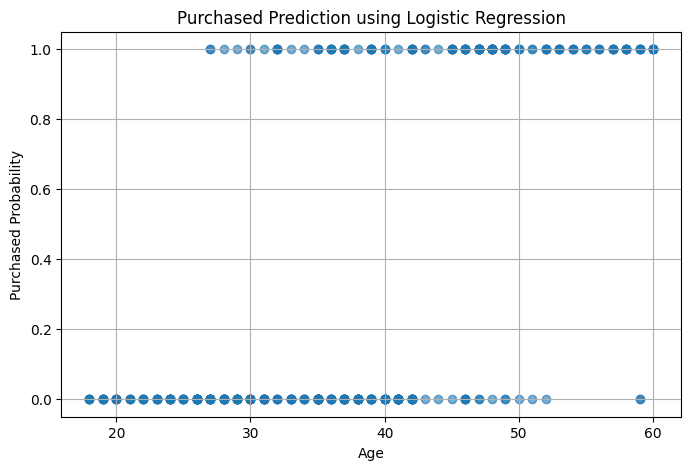

In [35]:
x_range = np.linspace(
    df["Age"].min(),
    df["Age"].max(),
    300
).reshape(-1, 1)

x_range_scaled = scaler.transform(x_range)

y_prob = model.predict_proba(x_range_scaled)[:, 1]

plt.figure(figsize=(8,5))

plt.scatter(
    df["Age"],
    df["Purchased"],
    alpha=0.6
)


plt.xlabel("Age")
plt.ylabel("Purchased Probability")
plt.title("Purchased Prediction using Logistic Regression")
plt.grid(True)

plt.show()